In [ ]:
import os
import numpy as np

from google.colab import drive

drive.mount('/content/drive', force_remount=False)

current_dir = os.getcwd()
# Google Colab path:
mnist_train_dataset = os.path.join("train-00000-of-00001.parquet")
mnist_test_dataset = os.path.join("test-00000-of-00001.parquet")
# Local path:
# mnist_train_dataset = os.path.join(".MNIST_digits", "mnist", "train-00000-of-00001.parquet")
# mnist_test_dataset = os.path.join(".MNIST_digits", "mnist", "test-00000-of-00001.parquet")

path_to_train_mnist_dataset = os.path.join(current_dir, mnist_train_dataset)
path_to_test_mnist_dataset = os.path.join(current_dir, mnist_test_dataset)

# Checkpoint is persisted on Google Drive and updated only when validation loss improves
checkpoint_dir = ".training_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "qnn_best_checkpoint.pt")


In [2]:
from QNN_files import (load_and_process_mnist_dataset,
					   prepare_train_val_precomputed,
					   prepare_test_precomputed,
					   train_QNN,
					   test_QNN
					   )

c:\Users\micha\OneDrive_PolSl\dokumenty\Doktorat\Python\geqie\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from sklearn.preprocessing import LabelEncoder
LABELS_TO_INCLUDE=[0, 1] #, 2, 3, 4, 5, 6, 7, 8, 9]
N_SAMPLES_PER_CLASS_TRAIN=10

label_encoder = LabelEncoder()
label_encoder.fit(LABELS_TO_INCLUDE)


X_train_val, y_train_val = load_and_process_mnist_dataset(
	labels_to_include=LABELS_TO_INCLUDE,
	n_samples_per_label=N_SAMPLES_PER_CLASS_TRAIN, 
	resize=(8, 8), 
	path_to_mnist_dataset=path_to_train_mnist_dataset)

y_train_val = label_encoder.transform(y_train_val)

NUM_CLASSES = np.unique(y_train_val).shape[0]

prepared_train_val = prepare_train_val_precomputed(
	X_train_val,
	y_train_val,
	val_size=0.2,
	batch_size=5,
	save_dir=".circuits",
	random_state=42,
	stratify=True
)
train_dir = prepared_train_val["train_dir"]
val_dir = prepared_train_val["val_dir"]

X_test, y_test = load_and_process_mnist_dataset(
	labels_to_include=LABELS_TO_INCLUDE, 
	n_samples_per_label=int(N_SAMPLES_PER_CLASS_TRAIN*0.2), 
	resize=(8, 8), 
	path_to_mnist_dataset=path_to_test_mnist_dataset)
y_test = label_encoder.transform(y_test)

prepared_test  = prepare_test_precomputed(
	X_test,
	y_test,
	batch_size=5,
	save_dir=".circuits",
	random_state=42,
	stratify=True
)
test_dir = prepared_test["test_dir"]

[train] saved: .circuits\train\batch_0000.npz
[train] saved: .circuits\train\batch_0001.npz
[train] saved: .circuits\train\batch_0002.npz
[train] saved: .circuits\train\batch_0003.npz
[val] saved: .circuits\val\batch_0000.npz
[test] saved: .circuits\test\batch_0000.npz


In [6]:
results_dict = train_QNN(
	epochs=2,
	num_classes=np.unique(y_train_val).shape[0],
	train_dir=train_dir,
	val_dir=val_dir,
	checkpoint_path=checkpoint_path,
	resume_training=True,
)


Training: 100%|██████████| 2/2 [00:49<00:00, 24.58s/it, loss=0.15, val_loss=0.05]


### Test

In [7]:
test_results = test_QNN(qnn_model=results_dict['qnn_model'], num_classes=np.unique(y_train_val).shape[0], test_dir=test_dir)

Test loss:  0.4115
Accuracy:   0.7500
Precision:  0.8333
Recall:     0.7500
F1-score:   0.7333

Confusion matrix:
[[1 1]
 [0 2]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



### Plots:

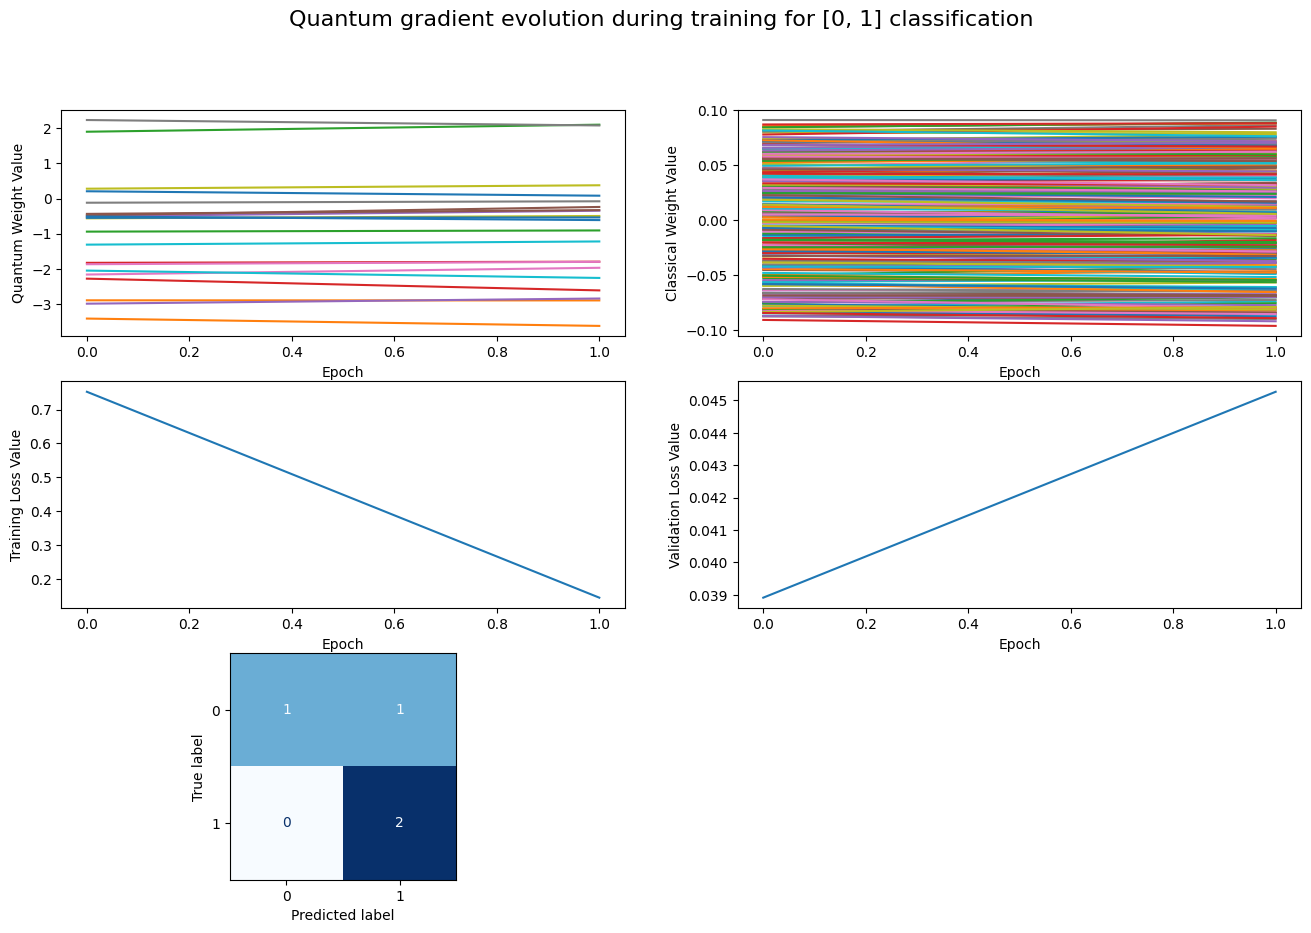

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle(f"Quantum gradient evolution during training for {LABELS_TO_INCLUDE} classification", fontsize=16)
quantum_weights_history = np.array(results_dict['quantum_layer_weights_history'])
for i in range(quantum_weights_history.shape[1]):
	ax[0, 0].plot(quantum_weights_history[:, i], label=f"Theta {i}")
ax[0, 0].set_xlabel("Epoch")
ax[0, 0].set_ylabel("Quantum Weight Value")

classical_weights_history = np.array(results_dict['classical_head_weights_history'])
for i in range(classical_weights_history.shape[1]):
	ax[0, 1].plot(classical_weights_history[:, i], label=f"Weight {i}")
ax[0, 1].set_xlabel("Epoch")
ax[0, 1].set_ylabel("Classical Weight Value")


ax[1, 0].plot(results_dict['train_losses'], label="Train Loss")
ax[1, 0].set_xlabel("Epoch")
ax[1, 0].set_ylabel("Training Loss Value")


ax[1, 1].plot(results_dict['val_losses'], label="Validation Loss")
ax[1, 1].set_xlabel("Epoch")
ax[1, 1].set_ylabel("Validation Loss Value")

cm = test_results["confusion_matrix"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS_TO_INCLUDE)
disp.plot(ax=ax[2, 0], cmap=plt.cm.Blues, colorbar=False)

ax[2, 1].axis("off")  # Hide the empty subplot

plt.show()